In [1]:
import os
import pandas as pd
import numpy as np

import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, RocCurveDisplay, precision_score, recall_score, accuracy_score, precision_recall_fscore_support, confusion_matrix
from scipy.interpolate import interp1d

import matplotlib.pyplot as plt

from utils.load_preprocess import load_preprocess
from utils.models import mlp_model
from utils.train_evaluate import summarize_diagnostics

# Initialize rng
rng = np.random.default_rng(2022)

# # Genes
# selecting top 100 genes gives 81 from feature selection using stability
# selecting top 500 genes gives 4111 from feature selection using stability
n_genes = 100

In [2]:
X, y = load_preprocess(n_genes)

0
1
2
3
4
5
6
7
8
9
[0.28409091 0.29166667 0.29545455 0.34469697 0.35984848 0.35984848
 0.36363636 0.36742424 0.37121212 0.37121212 0.38257576 0.38257576
 0.38257576 0.38636364 0.38636364 0.39015152 0.40151515 0.40530303
 0.40530303 0.40530303 0.40909091 0.40909091 0.40909091 0.40909091
 0.41287879 0.41287879 0.41666667 0.41666667 0.42045455 0.42045455
 0.42045455 0.42424242 0.4280303  0.4280303  0.4280303  0.4280303
 0.4280303  0.42992424 0.43181818 0.43181818 0.43181818 0.43560606
 0.43560606 0.43560606 0.43560606 0.44318182 0.44318182 0.4469697
 0.4469697  0.4469697  0.45075758 0.45075758 0.45075758 0.45454545
 0.45454545 0.45833333 0.45833333 0.45833333 0.46212121 0.46212121
 0.46212121 0.46590909 0.46590909 0.46590909 0.46590909 0.46590909
 0.46969697 0.46969697 0.46969697 0.46969697 0.46969697 0.46969697
 0.46969697 0.47348485 0.47348485 0.47348485 0.47727273 0.47727273
 0.47727273 0.47727273 0.48106061 0.48106061 0.48106061 0.48106061
 0.48484848 0.48484848 0.48484848 0.48484848

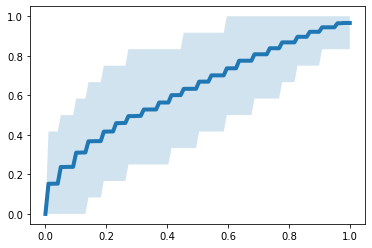

In [5]:
# How many experiments to run for generating CI
n_bootstrap = 10
n_iter = 100

# Build an FPR grid to generate TPR on a grid
fpr_grid_vec = np.linspace(0, 1, 100, endpoint=True)
tpr_grid_mat = np.zeros((len(fpr_grid_vec), n_bootstrap*n_iter))

# Maintain a list of AUROC scores
auroc_list = []

# index variable
count = 0

# Run experiments
for i in range(n_bootstrap):
    print(i)
    # Split data into train, validation, and test
    # train = 64%, val = 16%, test = 20%
    X_train_val, X_test, y_train_val, y_test = train_test_split(X,
                                                                y,
                                                                stratify=y,
                                                                test_size=0.2,
                                                                random_state=rng.integers(500000))
    X_train, X_val, y_train, y_val = train_test_split(X_train_val,
                                                    y_train_val,
                                                    stratify=y_train_val,
                                                    test_size=0.2,
                                                    random_state=rng.integers(500000))
    
    for j in range(n_iter):

        # define model
        tf.random.set_seed(rng.integers(500000))
        opt = Adam(learning_rate=0.0001)
        input_shape = X_train.shape[1]
        model = mlp_model(input_shape,
                          n_layers=2,
                          n_neurons=[64, 64],
                          opt=opt,
                          dropout=True,
                          dropout_rate=0.2,
                          batchnorm=True)
    #     model.summary()

        # Early stopping
        es = EarlyStopping(monitor='val_loss',
                           mode='min',
                           verbose=0,
                           patience=50,
                           restore_best_weights=True)

        # Train a model
        history = model.fit(X_train,
                            y_train,
                            epochs=200,
                            batch_size=16,
                            validation_data=(X_val, y_val),
                            verbose=0,
                            callbacks=[es])

        # Plot loss curves
    #     summarize_diagnostics(history)

        # Predict on test set
        y_pred = model.predict(X_test)

        # Measure ROC
    #     roc_auc = roc_auc_score(y_test, y_pred)
    #     print('AUROC:',roc_auc)
    #     test_acc = accuracy_score(y_test, np.around(y_pred))
    #     print('accuracy:', test_acc)
    #     p = precision_score(y_test, np.around(y_pred))
    #     print('Precision:', p)
    #     r = recall_score(y_test, np.around(y_pred))
    #     print('Recall:', r)
    #     confusionMatrix = confusion_matrix(y_test, np.around(y_pred))
    #     print('Confusion Matrix:\n', confusionMatrix)
        fpr, tpr, _ = roc_curve(y_true=y_test, y_score=y_pred)
        fpr = np.concatenate(([0], fpr, [1]))
        tpr = np.concatenate(([0], tpr, [1]))

        interpolator = interp1d(fpr, tpr, kind='nearest')

        tpr_grid_mat[:, count] = interpolator(fpr_grid_vec)

        auroc_list.append(roc_auc_score(y_test, y_pred))
#         print(roc_auc_score(y_test, y_pred))
        
        count += 1
    
# confidence interval for AUCs
sorted_scores = np.array(auroc_list)
sorted_scores.sort()
auroc_mean = np.mean(sorted_scores)
confidence_lower = sorted_scores[int(0.025 * len(sorted_scores))]
confidence_upper = sorted_scores[int(0.975 * len(sorted_scores))]
print(sorted_scores)
print('AUROC: {} [CI {} - {}]'.format(auroc_mean, confidence_lower, confidence_upper))

# Plot
# 90% confidence interval for ROC
tpr_grid_mats = np.sort(tpr_grid_mat, axis=1)
tpr_low_05 = tpr_grid_mats[:, int(0.05 * n_bootstrap * n_iter)]
tpr_top_95 = tpr_grid_mats[:, int(0.95 * n_bootstrap * n_iter)]
tpr_mean = np.mean(tpr_grid_mat, axis=1)

# plt.hold(True)
ax = plt.gca()  # kwargs.pop('ax', plt.gca())
base_line, = ax.plot(fpr_grid_vec, tpr_mean, '-', linewidth=4)
ax.fill_between(fpr_grid_vec, tpr_low_05, tpr_top_95, facecolor=base_line.get_color(), alpha=0.2)